# 1. Veri ve keşifsel analiz

**Soru:** Elimizdeki fiyat verisi güvenilir mi ve Nasdaq 100 hisselerinin getirileri nasıl bir dağılıma sahip?

Veri hattı: Yahoo Finance (yedek: Stooq) → `mi.clean` ile temizlik → SQLite (`prices`, `assets`, SEC tabloları).

In [1]:
import sys, sqlite3
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from mi import db, stats as st, events as ev, charts
%matplotlib inline
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
con = db.connect()
prices = pd.read_sql('SELECT * FROM prices', con)
close, volume = st.wide(prices), st.wide(prices, 'volume')
r = st.returns(close)
assets = pd.read_sql('SELECT * FROM assets', con).set_index('code')
print(f'{close.shape[1]} varlık, {close.index[0]:%Y-%m-%d} – {close.index[-1]:%Y-%m-%d}, {len(prices):,} fiyat satırı')

109 varlık, 2021-10-11 – 2026-10-09, 130,517 fiyat satırı


## 1.1 Veritabanı şeması ve satır sayıları

In [2]:
pd.DataFrame([(t, con.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]) for t in
 ['assets','prices','fundamentals','filings','insider_trades','fund_holdings']], columns=['tablo','satır'])

,tablo,satır
0,assets,109
1,prices,130517
2,fundamentals,63234
3,filings,4491
4,insider_trades,4011
5,fund_holdings,1108


## 1.2 Veri kalitesi
Temizleme kuralları: tekrar eden günler, sıfır/negatif fiyatlar, ertesi gün geri dönen tek günlük sıçramalar (hatalı fiyat), ortak takvime hizalama.

In [3]:
import json
from mi.config import SITE_OUT
q = pd.DataFrame(json.loads((SITE_OUT / 'quality.json').read_text())['assets']).T
q[['rows','first','last','spikes_fixed','calendar_filled']].sort_values('rows').head(10)

,rows,first,last,spikes_fixed,calendar_filled
HONA,82,2026-06-15,2026-10-09,0,0
SPCX,83,2026-06-12,2026-10-09,0,0
CRWV,386,2025-03-28,2026-10-09,0,0
SNDK,416,2025-02-13,2026-10-09,0,0
NBIS,494,2024-10-21,2026-10-09,0,0
ALAB,642,2024-03-20,2026-10-09,0,0
ARM,771,2023-09-14,2026-10-09,0,0
GEHC,957,2022-12-15,2026-10-09,0,0
CEG,1186,2022-01-19,2026-10-09,0,0
ORLY,1255,2021-10-11,2026-10-09,0,0


## 1.3 Getiriler normal dağılıyor mu?
Finans modellerinin çoğu getirilerin normal dağıldığını varsayar. Gerçekte "kalın kuyruk" vardır: aşırı günler normal dağılımın öngördüğünden çok daha sık yaşanır.

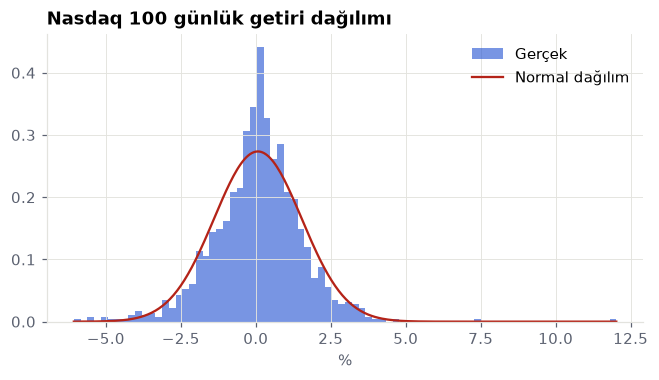

Çarpıklık 0.19, fazla basıklık 4.73
3 standart sapmayı aşan gün oranı: %0.88 (normal dağılımda %0.27 beklenir)
Jarque-Bera normallik testi p = 3.35e-256


In [4]:
x = r['NDX'].dropna() * 100
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(x, bins=80, density=True, color=charts.ACC, alpha=.6, label='Gerçek')
g = np.linspace(x.min(), x.max(), 300); ax.plot(g, stats.norm.pdf(g, x.mean(), x.std()), color=charts.DOWN, label='Normal dağılım')
ax.set_title('Nasdaq 100 günlük getiri dağılımı'); ax.set_xlabel('%'); ax.legend(frameon=False); plt.show()
k3 = (x.abs() > 3 * x.std()).mean() * 100
print(f'Çarpıklık {stats.skew(x):.2f}, fazla basıklık {stats.kurtosis(x):.2f}')
print(f'3 standart sapmayı aşan gün oranı: %{k3:.2f} (normal dağılımda %0.27 beklenir)')
print('Jarque-Bera normallik testi p =', f'{stats.jarque_bera(x).pvalue:.2e}')

**Yorum:** Fazla basıklık sıfırın belirgin üstündeyse ve Jarque-Bera p değeri çok küçükse normallik reddedilir. Pratik anlamı: oynaklıkla hesaplanan risk ölçüleri (ör. "%95 ihtimalle günlük kayıp şu kadarı geçmez") gerçek riski olduğundan küçük gösterir.

## 1.4 Aylık getiri ısı haritası (SQL ile)

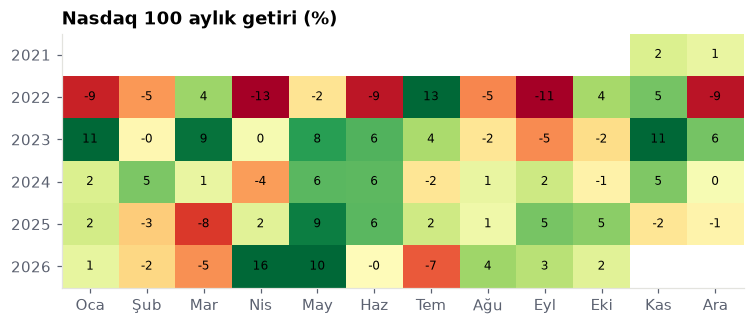

mo,01,02,03,04,05,06,07,08,09,10,11,12
ortalama,1.47,-0.98,0.45,-0.04,6.36,1.95,2.10,-0.14,-0.91,1.47,4.31,-0.55


In [5]:
m = pd.read_sql("""
WITH m AS (
  SELECT strftime('%Y', date) AS y, strftime('%m', date) AS mo, close,
         ROW_NUMBER() OVER (PARTITION BY strftime('%Y-%m', date) ORDER BY date DESC) AS rn
  FROM prices WHERE code = 'NDX')
SELECT y, mo, close FROM m WHERE rn = 1 ORDER BY y, mo""", con)
m['ret'] = m['close'].pct_change() * 100
hm = m.pivot(index='y', columns='mo', values='ret')
fig, ax = plt.subplots(figsize=(8, 3)); ax.grid(False)
im = ax.imshow(hm.values, cmap='RdYlGn', vmin=-10, vmax=10, aspect='auto')
ax.set_xticks(range(12), ['Oca','Şub','Mar','Nis','May','Haz','Tem','Ağu','Eyl','Eki','Kas','Ara'][:hm.shape[1]]); ax.set_yticks(range(len(hm)), hm.index)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        if not np.isnan(v): ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8)
ax.set_title('Nasdaq 100 aylık getiri (%)'); plt.show()
hm.mean().rename('ortalama').to_frame().T

## 1.5 Sektörler: getiri ve oynaklık

In [6]:
h = assets[assets.cls == 'hisse']
yr = r[h.index].iloc[-252:]
sec = pd.DataFrame({'getiri_1y': (1 + yr).prod() - 1, 'oynaklık': yr.std() * np.sqrt(252), 'sektör': h['sector']}).groupby('sektör').agg(['mean', 'count'])
sec.columns = ['getiri', 'n', 'oynaklık', '_']; sec = sec.drop(columns='_')
sec[['getiri', 'oynaklık']] *= 100
sec['getiri/oynaklık'] = sec['getiri'] / sec['oynaklık']
sec.sort_values('getiri/oynaklık', ascending=False)

,getiri,n,oynaklık,getiri/oynaklık
sektör,,,,
Yarı iletken,105.63,18,61.69,1.71
Teknoloji,99.90,25,60.11,1.66
Sağlık,69.25,11,48.25,1.44
Ulaştırma,29.81,2,29.84,1.00
Gıda ve içecek,14.74,5,24.27,0.61
Seyahat ve eğlence,18.25,3,33.65,0.54
Enerji ve kamu hizmeti,1.14,5,27.66,0.04
Otomotiv,1.44,2,36.13,0.04
Perakende,-0.33,10,29.24,-0.01


**Yorum:** Getiri/oynaklık oranı, sektörün aldığı her birim risk karşılığında ne kadar getiri verdiğini gösterir (basitleştirilmiş Sharpe oranı). Yüksek getiri tek başına iyi değildir; aynı getiriyi daha az oynaklıkla veren sektör daha verimlidir.